# HelioCloud 'The Cloud Way': S3 Storage + Dask CPUs
May 5, 2026

# Notebook to process data in SMCE helio-public S3 bucket using Dask

<i>Note:  This document is maintained through the SMCE HelioCloud github at github.com/heliocloud-data.</i>

This is a simple example showing how to get a list of FITS files, run them through Dask workers to pull them from disk and examine the header keyword(s).  The focus is not FITS handling per se, but the mechanics of accessing S3-backed object storage and distributing I/O-bound workloads across workers. The goal is to understand how to access inexpensive object storage and on-demand extra CPUs rather than laptop storage and laptop compute.

You can use this notebook to test out various parameters you might feed to Dask; Consider the 'batch size', number of workers, number of cores per worker and memory per worker. Use the dashboard link to inspect how Dask is performing. Try both manual and automatic scaling strategies. See if you can get it to process 100 files in 20 sec or less!

## First:  What is S3? 

Amazon S3 (Simple Storage Service) is an object store, not a POSIX filesystem. Objects are stored in buckets and addressed by key (a flat namespace). There are no true directories; “folders” are key prefixes.

S3 semantics differ from disk:

- No in-place modification; objects are immutable.
- No low-latency random write.
- Metadata and object listing are API operations.
- Throughput is optimized for large, sequential transfers.

Conceptually, S3 behaves more like a network-attached tape library than a block device: high capacity, high durability, optimized for streaming access, and tolerant of latency.

It allows people to query and access data from a common location reference.  The buckets can also be made web accessible to users outside of daskhub if web access is enabled.    

## Accessing S3 buckets

To get a list of the S3 buckets on the SMCE Daskhub, enter this at a terminal prompt : <br>
`aws s3 ls`

To view the contents of a specific bucket, reference it with s3:// <br>
`aws s3 ls s3://gov-nasa-hdrl-data1/`
>            PRE sdac/
>            PRE spdf/
>            PRE contrib/

`PRE` denotes a prefix (a key namespace convention).

The public HTTPS endpoint for this bucket is: https://<bucketname>.s3.us-east-1.amazonaws.com/

### Basic Operations

S3 operations are object-level API calls:

- List objects  
  `aws s3 ls s3://gov-nasa-hdrl-data1/path/`

- Upload object  
  `aws s3 cp file s3://gov-nasa-hdrl-data1/path/`

- Recursive upload  
  `aws s3 cp sourcedir/ s3://gov-nasa-hdrl-data1/path/ --recursive`

For restricted buckets, credentials (e.g., via MFA-backed profiles) are required.

All interactions are remote API calls; performance depends on network bandwidth, request concurrency, and object size—not local disk characteristics.

## Basic commands using S3 buckets

To create a new directory, just reference it:<br>
`aws s3 ls s3://helio-public/yourname/yourdir`

then you can copy to the bucket as if it was a unix folder:<br>
`aws s3 cp yourfile s3://helio-public/yourname/yourdir`

copying multiple files is a bit more intricate, you need to put the multiple files in a directory first:<br>
`aws s3 cp sourcedir/ s3://helio-public/yourname/yourdir --recursive`

if you need access to a bucket that has restricted access, you have to run aws-mfa first:<br>
`~/aws-mfa default`

where default is a profile. To see available profiles:<br>
`cat ~/.aws/credentials`

you may need to change it to have execute permission first:<br>
`chmod 755 ~/aws-mfa`

## What is Dask?

Dask is the tool for accessing additional CPUs quickly for your calculation.  Dask 'spins up' a cluster of temporary CPUs, you then throw your job at them and it intelligently distributes the workload, then gathers the results.  Typically up to 100 of these temporary workers are allowed for a HelioCloud.  Our quick demo here uses 5 CPUs ('workers'), each with 2 cores.

Dask provides distributed task scheduling and parallel execution across multiple worker processes or nodes.

A Dask cluster consists of:
- A scheduler (task graph orchestration)
- Workers (execution processes with configurable cores and memory)

In this context, Dask is used to parallelize many independent S3 object fetches and computations. This pattern is effective when latency and transfer time dominate over per-task CPU cost.

#### Import libraries, initialize objects and bring up cluster options widget

Instantiate a cluster and connect a `Client`. The cluster widget exposes scaling controls and links to the scheduler dashboard.

In [1]:
from dask_gateway import Gateway, GatewayCluster
gateway = Gateway()
options = gateway.cluster_options()

# We're setting some defaults here just for grins... 
# I like the pangeo/base-notebook image for the workers since it has almost every library you'd need on a worker
# In our environment, without setting these, the widget will default to the same image that the notebook itself is running, 
# as well as 2 cores and 4GB memory per worker

options.worker_cores=2
options.worker_memory=1

# This calls the widget
options  

#### Initialize the cluster and assign the client to the cluster, display the cluster widget

In [2]:
cluster = gateway.new_cluster(options)
client = cluster.get_client()
n_workers = 5
cluster.scale(n_workers)
client.wait_for_workers(n_workers)
cluster

#### Don't forget to scale your cluster to add workers, either manually or using adaptive scaling
#### Also, see that link in the cluster widget that says "Dashboard:"?  Click it to get to the Dask cluster dashboard
Remember, you can copy that URL into the Dask panel on the left

#### Now let's do some work.  Since we've assigned a client to the cluster object, any call to a dask object will automatically get sent to the cluster workers 

In [3]:
from dask.distributed import Client

client = Client(cluster)
client

Connection method: Cluster object,Cluster type: dask_gateway.GatewayCluster
Dashboard: /services/dask-gateway/clusters/daskhub.f3c3ac16a3e34ef295d8be246a47393f/status,


In [4]:
%%time

import dask.array as da
a = da.random.normal(size=(30000,30000), chunks=(1000, 1000))
out = a.mean().compute()
print(out)


5.43218366205152e-05
CPU times: user 425 ms, sys: 72 ms, total: 497 ms
Wall time: 8.25 s


#### When you're finished, shut down the cluster to release the resources (it'll happen automatically after a set idle time)

In [5]:
cluster.shutdown()

A few troubleshooting functions

In [6]:
gateway.get_versions()

{'server': {'version': '2024.1.0'}, 'client': {'version': '2024.1.0'}}

In [7]:
gateway.list_clusters()

[ClusterReport<name=daskhub.b462381821dc48c8a28b2af6424d6033, status=RUNNING>,
 ClusterReport<name=daskhub.f3c3ac16a3e34ef295d8be246a47393f, status=RUNNING>]

### Scaling and Monitoring

Explicitly scale the cluster (fixed worker count) or enable adaptive scaling.

Use the Dask dashboard to inspect:
- Task graph execution
- Worker utilization
- Network transfer
- Memory pressure

When working against S3, network and object fetch latency are often the primary constraints.

## With Actual Data

### Example: Processing Public SDO AIA Data

We now perform a representative workflow:

1. Enumerate SDO AIA FITS objects in a public S3 bucket.
2. Launch a Dask cluster.
3. Distribute object fetch + header inspection across workers.
4. Aggregate results.

The key objective is to illustrate how object storage access patterns interact with distributed task scheduling.

Summarizing, here is a sample scientific task.  We will fetch SDO AIA files stored in the NASA public (ODR) S3 bucket, spin up a Dask cluster of 10 workers, then send 1 day's worth of data (360 files) to compute the average irradiance, and plot it.

In [8]:
# setup to access S3 transparently
import boto3
from botocore import UNSIGNED
from botocore.config import Config

# necessary imports for Dask
import dask
from dask.distributed import Client

# imports for handling scientific files and doing basic searching
import io
import re
import logging
import s3fs
from os import listdir
from os.path import isfile, join
from astropy.io import fits

## 0. Configuration 

In [9]:
# name of the bucket to upload to
bucket_name = 'gov-nasa-hdrl-data1'

# location in the bucket to use (a days worth of 211 A data from AIA on SDO for the date 2022-11-27)
bucket_path = 'sdac/sdo/aia/20221127/0211/'

## 0. Configuration

Define tunable parameters:

- Worker count
- Cores per worker
- Memory per worker
- Batch size (objects per task)

These parameters affect concurrency, memory footprint, and S3 request rate.

Adjust configuration values to explore trade-offs between:

- High concurrency (many small tasks)
- Larger batch sizes (fewer S3 round-trips)
- Memory constraints per worker
- Network saturation

(Feel free to play with the following values to optimize the performance.)

In [10]:
# number of workers to use, for automatic scaling, our max number
n_workers = 10

# memory per worker (in Gb)
w_memory = 2

# cores per worker
w_cores = 2

# number of files to test against (360 max)
n_files = 100

# Number of files we release to be worked on by all workers at a time
# the higher the number the more files being processed concurrently, but also
# the greater the memory consumed. 
batch_size = 50

## 1. Initialize the cluster and assign the client to the cluster, display the cluster widget

### Initialize Cluster

Create and configure the Dask cluster, then attach a `Client`. Confirm connectivity via the cluster widget.

In [11]:
from dask_gateway import Gateway, GatewayCluster
gateway = Gateway()
options = gateway.cluster_options()

# We're setting some defaults here just for grins... 
# I like the pangeo/base-notebook image for the workers since it has almost every library you'd need on a worker
# In our environment, without setting these, the widget will default to the same image that the notebook itself is running, 
# as well as 2 cores and 4GB memory per worker

options.worker_cores=w_cores
options.worker_memory=w_memory
# options

In [12]:
cluster = gateway.new_cluster(options)
client = cluster.get_client()

# use Manual (if False, then uses Automatic scaling)
use_manual_scaling = True

if use_manual_scaling:
    # manual scaling (n_workers defined above)
    cluster.scale(n_workers)
else:
    # Adaptively scale between 1 and n_workers (the max)
    cluster.adapt(minimum=1, maximum=n_workers)

# uncomment this if you want to use the GUI
#cluster

In [13]:
# create client, show url we can go to to monitor progress
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: dask_gateway.GatewayCluster
Dashboard: /services/dask-gateway/clusters/daskhub.1e50763a8f694041928fead71e9b3b4b/status,


## 2. Scan data from bucket and make a simple list of file names

While we recommend using 'import cloudcatalog' to fetch catalog lists, below we use the bare metal read from S3 to give a generalized example.

### Enumerate Objects in the Bucket

Scan the S3 bucket and construct a list of object keys.

While higher-level catalog services are recommended for production workflows, here we perform direct S3 listing to expose the underlying mechanics. Each listing operation is an API request and may paginate for large prefixes.


In [14]:
# get our list of files/s3 objects
import os
import json
if os.path.isfile('Tools/s3_data.json'):
    with open ('Tools/s3_data.json') as f:
        s3_files = json.load(f)['files']
else:
    # initialize connection to S3 bucket
    s3_client = boto3.client('s3', config=Config(signature_version=UNSIGNED))
    objs = s3_client.list_objects(Bucket=bucket_name, Prefix=bucket_path)
    """ Iterates through all the objects, doing the pagination for you. Each obj
     is an ObjectSummary, so it doesn't contain the body. You'll need to call
     get to get the whole body.
    """
    s3_files = []
    for obj in objs['Contents']: #bucket.objects.all():
        key = obj['Key']
        if re.search ('fits', key):
            s3_files.append('s3://'+bucket_name+'/'+key) 
    # write / cache files to local listing (speed purposes)
    with open('Tools/s3_data.json', 'w') as outfile:
        json.dump({'files' : s3_files}, outfile)
        print("Generated Tools/s3_data.json list of files for demo.")
    
print(len(s3_files),"files available, sample file:",s3_files[0])

360 files available, sample file: s3://gov-nasa-hdrl-data1/sdac/sdo/aia/20221127/0211/sdo_aia_h2_20221127T000000_0211_v1.fits


## 3. Define some routines we will use for doing work with Dask

### Define Worker Routines

Define functions that:

- Retrieve objects from S3
- Parse FITS headers
- Extract relevant metadata

Each invocation results in one or more remote object fetches. Efficient design minimizes redundant reads and maximizes sequential access within a task.

In [15]:
import astropy.io.fits
import s3fs

def DO_SCIENCE(mydata):
    # you can put better science here
    iirad = mydata.mean()
    return iirad

# these are variable helpful handler functions
def s3url_to_bucketkey(s3url: str): # -> Tuple[str, str]:
    """
    Extracts the S3 bucket name and file key from an S3 URL.
    e.g. s3://mybucket/mykeypart1/mykeypart2/fname.fits -> mybucket, mykeypart1/mykeypart2/fname.fits
    """
    name2 = re.sub(r"s3://","",s3url)
    s = name2.split("/",1)
    return s[0], s[1]

def process_fits_s3(s3key:str): # -> Tuple[str, float]:
    """ For a single FITS file, read it from S3, grab the header and
        data, then do the DO_SCIENCE() call of choice
    """
    sess = boto3.session.Session() # do this each open to avoid thread problem 'credential_provider'
    s3c = sess.client("s3")
    mybucket,mykey = s3url_to_bucketkey(s3key)
    try:
        fobj = s3c.get_object(Bucket=mybucket,Key=mykey)
        rawdata = fobj['Body'].read()
        bdata = io.BytesIO(rawdata)
        hdul = astropy.io.fits.open(bdata,memmap=False)        
        date = hdul[1].header['T_OBS']
        irrad = DO_SCIENCE(hdul[1].data)
        print(date,irrad)
    except:
        print("Error fetching ",s3key)
        date, irrad = None, None
        
    return date, irrad

def work_on_data (client:dask.distributed.client.Client, bucket_name:str, files:list=[])->int:
    """ 
    Main routine which Dask will use to 'do work'. Each worker will run this.
    """
    # simple version step 1, do it
    mean_irrad = client.map(process_fits_s3, s3_files)

    # trigger distributed task, marshall result back to local memory
    all_data = client.gather(mean_irrad)

    # return the primary header back for analysis
    return all_data

## 4. Executing Work

### Do the cloud processing, using Dask to 'burst' into other VMs

Using our gathered list of FITS files, chunk it out in batches and provide file list chunks to the workers.

Once a `Client` is attached, Dask collections and delayed functions are executed on workers. Each worker independently retrieves required S3 objects via the S3 API.

### Distributed Processing

Partition the object list into batches and submit them to Dask workers.

Each worker:
1. Issues S3 GET requests for its assigned objects.
2. Streams object content over the network.
3. Performs local computation.
4. Returns aggregated results to the scheduler.

This “burst” pattern scales read concurrency but remains bounded by S3 request rate, object size, and network bandwidth. Understanding these constraints is essential when treating S3 as a scientific data backend.

In [16]:
%%time
if n_files > len(s3_files):
    n_files = len(s3_files)
    
def chunks(lst, n):
    """ program to divide our file list into chunks for each worker """
    n = max(1, n)
    return (lst[i:i+n] for i in range(0, len(lst), n))

client.wait_for_workers(n_workers)

print (f"workers: {n_workers}, cores/worker:{w_cores}, mem/worker: {w_memory}")
for files_to_process in chunks(s3_files[:n_files], batch_size):
    returns = work_on_data(client, bucket_name, files_to_process)
    print (f"client:%s Finished %s files" % (client,len(returns)))
print(returns)

Exception in callback None()
handle: <Handle cancelled>
Traceback (most recent call last):
  File "/srv/conda/envs/notebook/lib/python3.11/site-packages/tornado/iostream.py", line 1363, in _do_ssl_handshake
    self.socket.do_handshake()
  File "/srv/conda/envs/notebook/lib/python3.11/ssl.py", line 1382, in do_handshake
    self._sslobj.do_handshake()
ssl.SSLCertVerificationError: [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate (_ssl.c:1016)

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/srv/conda/envs/notebook/lib/python3.11/asyncio/events.py", line 84, in _run
    self._context.run(self._callback, *self._args)
  File "/srv/conda/envs/notebook/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 208, in _handle_events
    handler_func(fileobj, events)
  File "/srv/conda/envs/notebook/lib/python3.11/site-packages/tornado/iostream.py", line 691, in _handle_events
    self._h

workers: 10, cores/worker:2, mem/worker: 2
client:<Client: 'tls://192.168.3.19:8786' processes=6 threads=12, memory=12.00 GiB> Finished 360 files
client:<Client: 'tls://192.168.3.19:8786' processes=10 threads=20, memory=20.00 GiB> Finished 360 files
[('2022-11-26T23:59:59.076', 246.10400724), ('2022-11-27T00:03:59.075', 246.05598848), ('2022-11-27T00:07:59.077', 245.98559872), ('2022-11-27T00:11:59.076', 245.91050752), ('2022-11-27T00:15:59.077', 245.93071612), ('2022-11-27T00:19:59.077', 245.9433298), ('2022-11-27T00:23:59.076', 245.96948512), ('2022-11-27T00:27:59.076', 245.96179056), ('2022-11-27T00:31:59.076', 245.95739584), ('2022-11-27T00:35:59.077', 245.99036456), ('2022-11-27T00:39:59.076', 246.03724508), ('2022-11-27T00:43:59.083', 246.12423788), ('2022-11-27T00:47:59.083', 246.15225212), ('2022-11-27T00:51:59.076', 246.1959786), ('2022-11-27T00:55:59.076', 246.21038544), ('2022-11-27T00:59:59.077', 246.29276376), ('2022-11-27T01:03:59.080', 246.21790132), ('2022-11-27T01:07:5

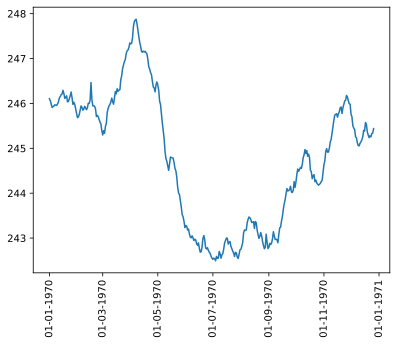

In [17]:
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline 
# Optional, have Matplotlib create vector (svg) instead of raster (png) images
%config InlineBackend.figure_formats = ['svg'] 
dates, values = zip(*returns)
plt.plot(dates, values) #, marker='o', linestyle='-')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=90)
plt.show()

In [ ]:
yn = input("Done with cluster, able to shut it down? y/n: ")
if yn.startswith('y'):
    client.close()
    cluster.shutdown()

Exception in callback None()
handle: <Handle cancelled>
Traceback (most recent call last):
  File "/srv/conda/envs/notebook/lib/python3.11/site-packages/tornado/iostream.py", line 1363, in _do_ssl_handshake
    self.socket.do_handshake()
  File "/srv/conda/envs/notebook/lib/python3.11/ssl.py", line 1382, in do_handshake
    self._sslobj.do_handshake()
ssl.SSLCertVerificationError: [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate (_ssl.c:1016)

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/srv/conda/envs/notebook/lib/python3.11/asyncio/events.py", line 84, in _run
    self._context.run(self._callback, *self._args)
  File "/srv/conda/envs/notebook/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 208, in _handle_events
    handler_func(fileobj, events)
  File "/srv/conda/envs/notebook/lib/python3.11/site-packages/tornado/iostream.py", line 691, in _handle_events
    self._h